In [13]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special

# --- constantes ----
CENTRAL_FLUX = 0
UPWIND_FLUX = 1

A = np.array([0.0,
-567301805773.0 / 1357537059087.0,
-2404267990393.0 / 2016746695238.0,
-3550918686646.0 / 2091501179385.0,
-1275806237668.0 / 842570457699.0])

B = np.array([1432997174477.0 / 9575080441755.0,
5161836677717.0 / 13612068292357.0,
1720146321549.0 / 2090206949498.0,
3134564353537.0 / 4481467310338.0,
2277821191437.0 / 14882151754819.0])

# --- parâmetros físicos ---
eps = 1
mu = 1

# --- domínio ---
vp = 1 / np.sqrt(eps * mu)
Z = np.sqrt(mu / eps)
xl, xr = 0, 1

# --- retorna matriz D - diferenciação ---
def get_D_matrix(nodes):
    N = len(nodes) - 1
    w = np.ones(N + 1)
    
    for j in range(N + 1):
        for i in range(N + 1):
            if i != j:
                w[j] *= 1.0 / (nodes[j] - nodes[i])
    D = np.zeros((N + 1, N + 1))
    
    for i in range(N + 1):
        for j in range(N + 1):
            if i != j:
                D[i, j] = (w[j] / w[i]) / (nodes[i] - nodes[j])
        D[i, i] = -np.sum(D[i, :])
        
    return D

# --- retorna fluxo numérico ---
def numerical_flux(uL, uR, a, flux_type):
    match flux_type:
        case 0:
            return 0.5 * a * (uL + uR)
        case 1:
            return a * uL if a > 0 else a * uR
        case _: # fallback central flux
            return 0.5 * a * (uL + uR)
        
# --- retorna pontos GLL de ordem polinomial N ---
def get_GLL_nodes(N):
    internal_nodes, _ = scipy.special.roots_jacobi(N - 1, 1, 1)
    r = np.concatenate([[-1.0], internal_nodes, [1.0]]) # elemento de referência
    return r

# --- retorna pesos dos nós GLL de ordem polinomial N ---
def get_GLL_weights(nodes, N):
    N = len(nodes) - 1

    # Legendre polynomial of degree N
    P = scipy.special.legendre(N)

    # Evaluate P_N(x_i)
    PN = np.polyval(P, nodes)

    # Compute weights
    w = 2.0 / (N * (N + 1) * PN**2)

    return w
    
# --- operador DG ---
def build_dg_operator(K, N, a, flux_type):
    dx_elem = (xr - xl) / K
    xi = get_GLL_nodes(N)
    D_ref = get_D_matrix(xi)
    D_phys = (2.0 / dx_elem) * D_ref
    w = get_GLL_weights(xi, N)
    M_local = w * dx_elem / 2.0
    
    # Coordenadas físicas dos nós
    x_nodes = np.zeros((K, N + 1))
    for k in range(K):
        xL = xl + k * dx_elem
        x_nodes[k, :] = xL + 0.5 * (xi + 1) * dx_elem
        
    return {
        'K': K, 'N': N, 'dx_elem': dx_elem,
        'D_phys': D_phys, 'M_local': M_local,
        'x_nodes': x_nodes, 'a': a, 'flux_type': flux_type
    }
    
def rhs(u_flat, op):
    # puxa os dados do operador DG
    K, N = op['K'], op['N']
    D = op['D_phys']
    M = op['M_local']
    a = op['a']
    flux_type = op['flux_type']
    
    u = u_flat.reshape((K, N + 1, 2))
    du = np.zeros_like(u)
    
    # itera sobre cada elemento e vai resolvendo em cada um
    for k in range(K):
        du[k,:,0] = - (D @ u[k,:,1]) / eps
        du[k,:,1] = - (D @ u[k,:,0]) / mu
        
        if k == K-1:
            Ey_int = u[k, N, 0]
            Hz_int = u[k, N, 1]
            Ey_star = 0.0
            Hz_star = Hz_int
        else:
            Ey_L = u[k, N, 0]; Hz_L = u[k, N, 1]
            Ey_R = u[k+1, 0, 0]; Hz_R = u[k+1, 0, 1]
            if flux_type == 'central':
                Ey_star = 0.5*(Ey_L + Ey_R)
                Hz_star = 0.5*(Hz_L + Hz_R)
            else: # upwind
                Ey_star = 0.5*(Ey_L + Ey_R) + 0.5*Z*(Hz_L - Hz_R)
                Hz_star = 0.5*(Hz_L + Hz_R) + 0.5/Z*(Ey_L - Ey_R)
        
        # Correção no último nó (N): sinal negativo
        du[k, N, 0] += - (Hz_star - u[k, N, 1]) / M[N]
        du[k, N, 1] += - (Ey_star - u[k, N, 0]) / M[N]
        
        # --- Face esquerda (x_L) ---
        if k == 0:
            # PEC em x=0
            Ey_int = u[k, 0, 0]
            Hz_int = u[k, 0, 1]
            Ey_star = 0.0
            Hz_star = Hz_int
        else:
            Ey_L = u[k-1, N, 0]; Hz_L = u[k-1, N, 1]
            Ey_R = u[k, 0, 0]; Hz_R = u[k, 0, 1]
            if flux_type == 'central':
                Ey_star = 0.5*(Ey_L + Ey_R)
                Hz_star = 0.5*(Hz_L + Hz_R)
            else:
                Ey_star = 0.5*(Ey_L + Ey_R) + 0.5*Z*(Hz_L - Hz_R)
                Hz_star = 0.5*(Hz_L + Hz_R) + 0.5/Z*(Ey_L - Ey_R)
                
        # Correção no primeiro nó (0): sinal positivo
        du[k, 0, 0] += (Hz_star - u[k, 0, 1]) / M[0]
        du[k, 0, 1] += (Ey_star - u[k, 0, 0]) / M[0]
        
    return du.flatten()

# low storage Range Kutta quarta ordem
def lsrk4_step(u, rhs_func, dt, op):
    q = np.zeros_like(u)
    for i in range(5):
        q = A[i] * q + dt * rhs_func(u, op)
        u = u + B[i] * q
        
    return u

In [14]:
def DGTD(K, N, CFL, T_final, a, flux_type):
    # gera o operador
    dg_operator = build_dg_operator(K, N, a, flux_type)
    x_nodes = dg_operator['x_nodes']
    
    # discretização
    dx = dg_operator['dx_elem']
    dt = CFL * dx / (np.abs(a) * (N + 1) ** 2)
    Nt = max(1, int(T_final / dt))
    dt = T_final / Nt # evita erro de arrendondamento
    
    # Condição inicial
    u = np.stack([np.sin(np.pi * x_nodes), np.zeros_like(x_nodes)], axis=-1).flatten().copy()
    
    # snapshots
    u_history = []
    snapshots_list = np.linspace(0, Nt - 10, 6)
    
    print("INICIANDO MARCHA NO TEMPO")
    print(f"dx = {dx:.3e}, dt = {dt:.3e}, Nt = {Nt}")
    
    # marcha no tempo
    for step in range(Nt):
        u = lsrk4_step(u, rhs, dt, dg_operator)
        
        if step in snapshots_list:
            u_history.append(u.reshape((K, N+1, 2)))
        
    return u_history, dx, dt, snapshots_list

# --- Parâmetros de simulação ----
K = 64 # numero de elementos
N = 4 # ordem polinomial dentro dos elementos
CFL = 0.2
T_final = 3

u_history, dx, dt, snapshots_list = DGTD(K, N, CFL, T_final, vp, UPWIND_FLUX)

INICIANDO MARCHA NO TEMPO
dx = 1.562e-02, dt = 1.250e-04, Nt = 24000


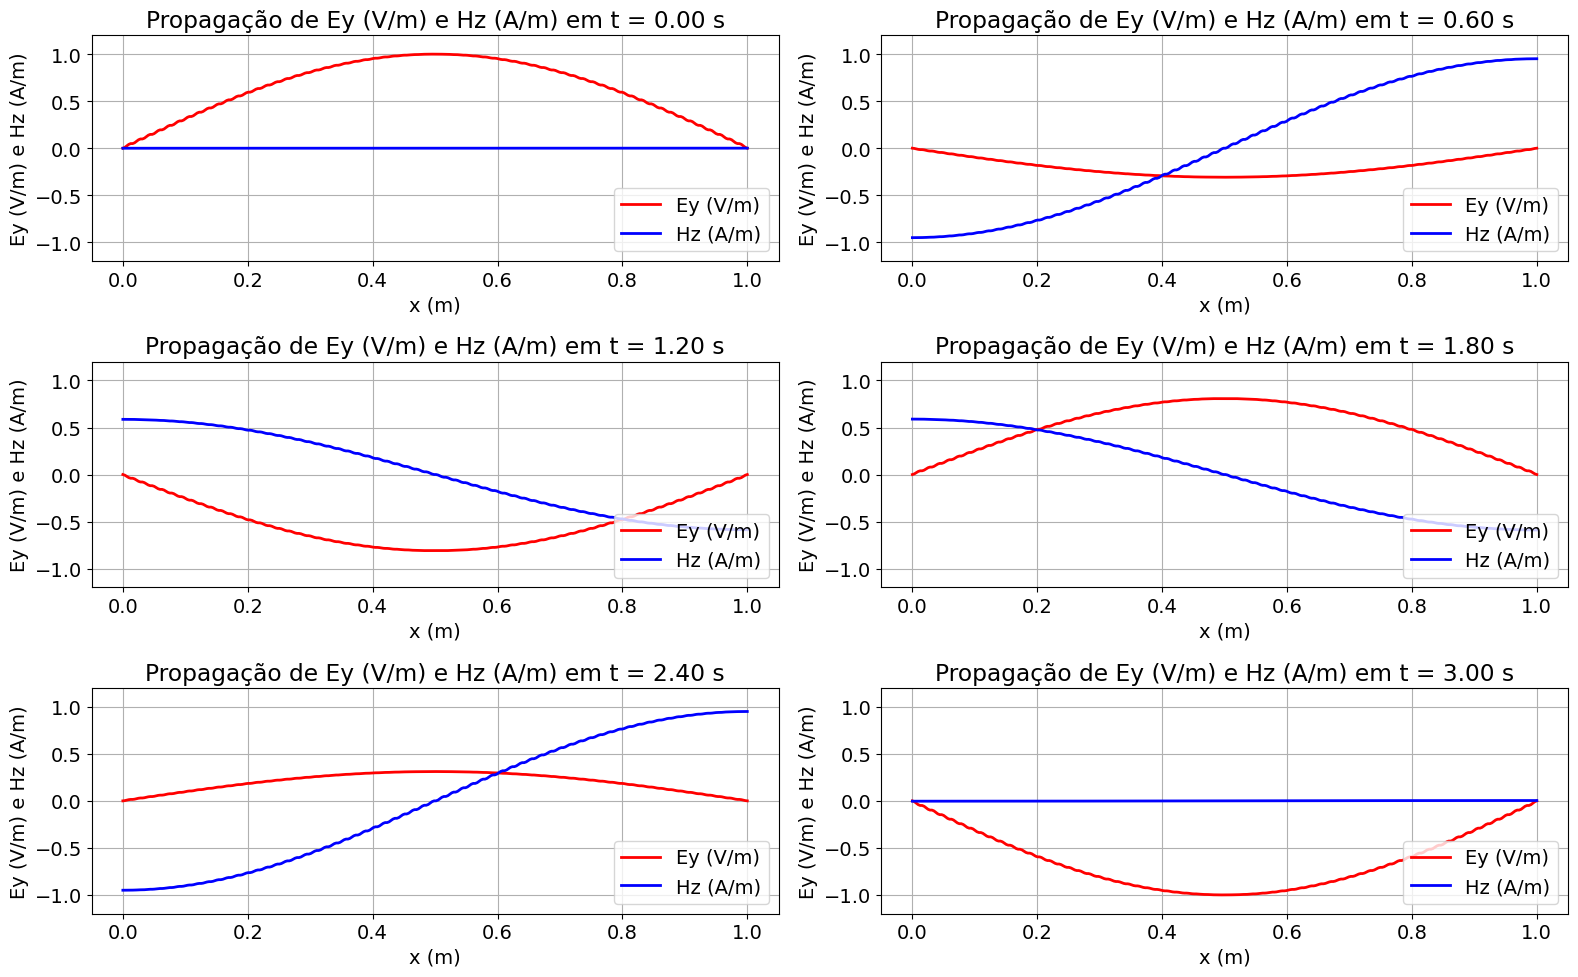

In [15]:
plt.rcParams.update({
    "font.size": 14
})

fig, axes = plt.subplots(3, 2, figsize=(16, 10))
peak_position = []
time_position = []

for i, ax in enumerate(axes.flat):
    Ey_num = u_history[i][:,:,0]
    Hz_num = u_history[i][:,:,1]
    x_range = np.linspace(xl, xr, int(len(Ey_num.flatten())))
    ax.plot(x_range, Ey_num.flatten(), linewidth=2, color='red', label="Ey (V/m)")
    ax.plot(x_range, Hz_num.flatten(), linewidth=2, color='blue', label="Hz (A/m)")
    ax.set_xlabel('x (m)')
    ax.set_ylabel('Ey (V/m) e Hz (A/m)')
    ax.set_title(f'Propagação de Ey (V/m) e Hz (A/m) em t = {dt * snapshots_list[i]:.2f} s')
    ax.set_ylim(-1.2, 1.2)
    ax.grid()
    ax.legend(loc='lower right')
    
    peak_position.append(x_range[np.argmax(Ey_num.flatten())])
    time_position.append(dt * snapshots_list[i])

plt.tight_layout()
plt.show()

In [16]:
def u_exact(xt, tt):
    return np.sin(np.pi*(xt)) * np.cos(np.pi * tt)

for i in range(6):
    current_dt = dt * snapshots_list[i]
    x_range = np.linspace(xl, xr, int(len(u_history[i][:,:,0].flatten())))
    
    u_exact_calc = u_exact(x_range, current_dt)
    u_numerical =  u_history[i][:,:,0].flatten()
    L2 = np.sqrt(np.sum((u_numerical - u_exact_calc)**2))

    print(L2)


0.07740104772710685
0.025493462615467356
0.0620012553403054
0.06333152334511553
0.023378764854129944
0.0774054935424857


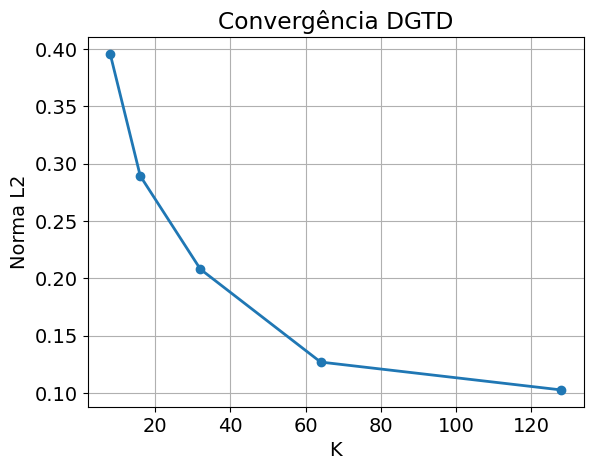

In [17]:
x_teste = [8, 16, 32, 64, 128]
y_teste = [0.3957, 0.2893, 0.2080, 0.1270, 0.1027]

plt.plot(x_teste, y_teste, 'o-', linewidth=2, markersize=6)

plt.xlabel("K")
plt.ylabel("Norma L2")
plt.title("Convergência DGTD")
plt.grid(True)

plt.show()

Text(0.5, 0, 'Posição (m)')

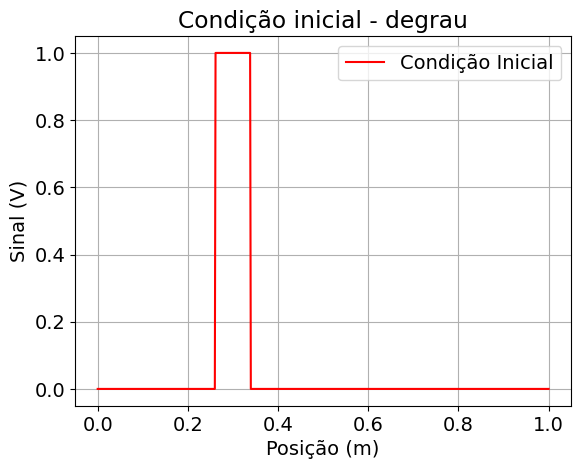

In [18]:
x_range = np.linspace(xl, xr, int(len(u_history[5].flatten())))
u_step = np.where(np.abs(x_range - 0.3) <= (5 * dx)/2, 1.0, 0.0)
plt.plot(x_range, u_step, color='red', label='Condição Inicial')
plt.title('Condição inicial - degrau')
plt.grid()
plt.legend()
plt.ylabel('Sinal (V)')
plt.xlabel('Posição (m)')